## Initial Setup and Library Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Loading

In [2]:
file_path = r"C:\Users\anmol\Desktop\Courseworks\AI\dataverse_files\2007.csv.bz2"
df = pd.read_csv(file_path, compression="bz2")

## Initial Data Exploration

In [3]:
print(df.columns)
print(df.head())

Index(['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime',
       'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum', 'TailNum',
       'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay',
       'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay'],
      dtype='object')
   Year  Month  DayofMonth  DayOfWeek  DepTime  CRSDepTime  ArrTime  \
0  2007      1           1          1   1232.0        1225   1341.0   
1  2007      1           1          1   1918.0        1905   2043.0   
2  2007      1           1          1   2206.0        2130   2334.0   
3  2007      1           1          1   1230.0        1200   1356.0   
4  2007      1           1          1    831.0         830    957.0   

   CRSArrTime UniqueCarrier  FlightNum  ... TaxiIn  TaxiOut  Cancelled  \
0        1340            WN       2891  ...    

Data Cleaning: Removing Invalid Flights

In [4]:
df = df[(df["Cancelled"] == 0) & (df["Diverted"] == 0)]

Target Variable Construction (ARR_DEL15)

In [32]:
df["ARR_DEL15"] = (df["ArrDelay"] >= 15).astype(int)

Target Variable Distribution Analysis

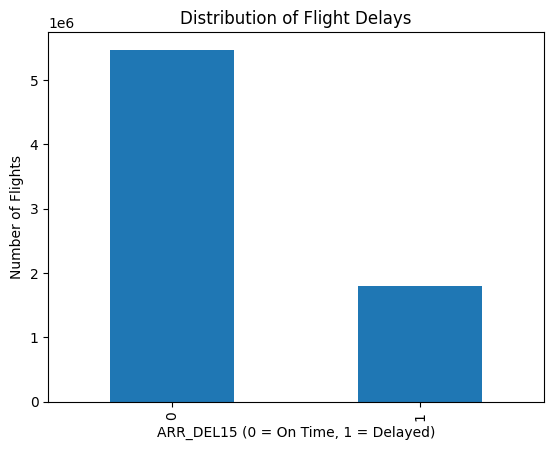

In [6]:
plt.figure()
df["ARR_DEL15"].value_counts().plot(kind="bar")
plt.xlabel("ARR_DEL15 (0 = On Time, 1 = Delayed)")
plt.ylabel("Number of Flights")
plt.title("Distribution of Flight Delays")
plt.show()


Feature Engineering: Scheduled Departure Hour

In [7]:
df = df.dropna(subset=["CRSDepTime"])
df["DEP_HOUR"] = (df["CRSDepTime"] // 100).astype(int)


Feature Selection (Pre-Departure Features Only)

In [33]:
features = [
    "Month",
    "DayOfWeek",
    "DEP_HOUR",
    "Distance"
]

X = df[features]
y = df["ARR_DEL15"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Handling Missing Values

In [9]:
X = X.dropna()
y = y.loc[X.index]

Train–Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Feature Scaling

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Before and After Scaling Visualization

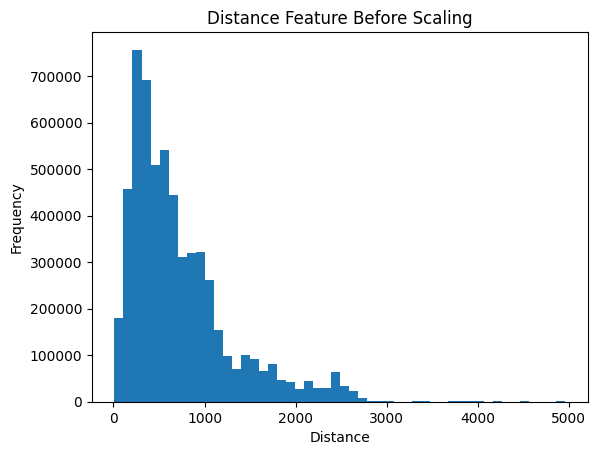

In [35]:
plt.figure()
plt.hist(X_train["Distance"], bins=50)
plt.title("Distance Feature Before Scaling")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()


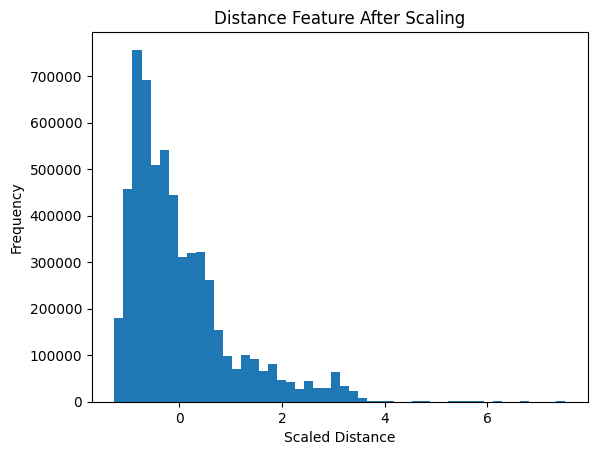

In [ ]:
plt.figure()
plt.hist(X_train_scaled[:, features.index("Distance")], bins=50)
plt.title("Distance Feature After Scaling")
plt.xlabel("Scaled Distance")
plt.ylabel("Frequency")
plt.show()

Logistic Regression Model Training

In [13]:
model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Model Prediction

In [14]:
y_pred = model.predict(X_test_scaled)

Model Evaluation (Text Output)

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7520951054872039

Classification Report:
               precision    recall  f1-score   support

           0       0.75      1.00      0.86   1094394
           1       0.19      0.00      0.00    360664

    accuracy                           0.75   1455058
   macro avg       0.47      0.50      0.43   1455058
weighted avg       0.61      0.75      0.65   1455058



Confusion Matrix Visualization

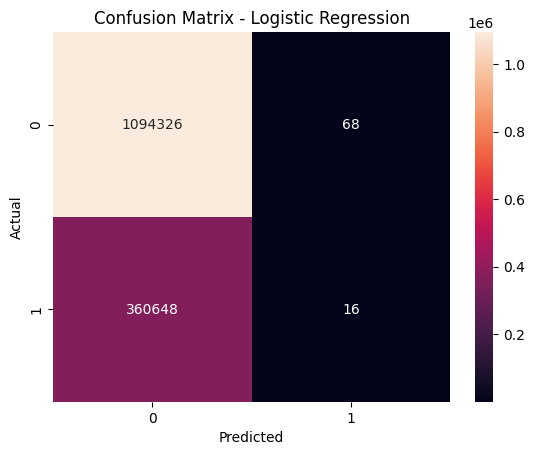

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


Logistic Regression Coefficient Analysis

In [17]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

print(coef_df)


     Feature  Coefficient
0      Month    -0.023184
1  DayOfWeek     0.001599
2   DEP_HOUR     0.373242
3   Distance     0.069249


Logistic Regression Coefficient Visualization

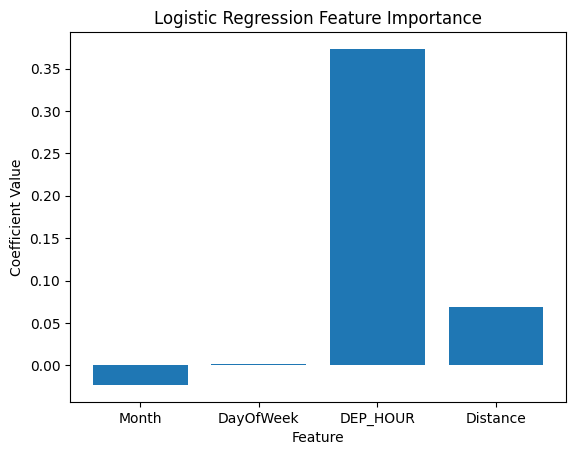

In [18]:
plt.figure()
plt.bar(coef_df["Feature"], coef_df["Coefficient"])
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.title("Logistic Regression Feature Importance")
plt.show()


# Random Forest

Random Forest Model Training

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Random Forest Prediction

In [20]:
y_pred_rf = rf_model.predict(X_test)

Random Forest Evaluation (Text Output)

In [21]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n",
      classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.7295221221422101

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.89      0.83   1094394
           1       0.42      0.23      0.30    360664

    accuracy                           0.73   1455058
   macro avg       0.60      0.56      0.57   1455058
weighted avg       0.69      0.73      0.70   1455058



Random Forest Confusion Matrix Visualization

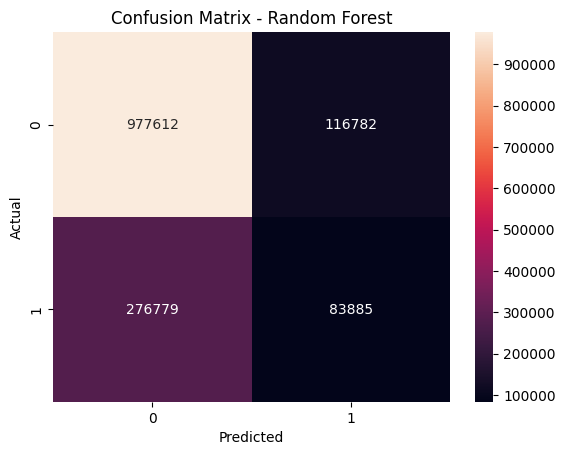

In [22]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

Random Forest Feature Importance Visualization

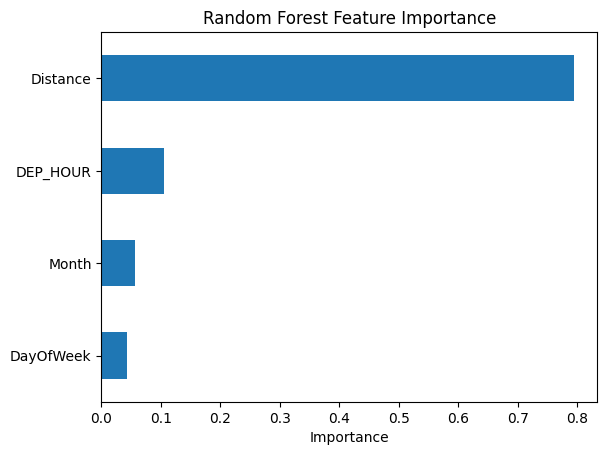

Random Forest Accuracy: 0.7295221221422101

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.89      0.83   1094394
           1       0.42      0.23      0.30    360664

    accuracy                           0.73   1455058
   macro avg       0.60      0.56      0.57   1455058
weighted avg       0.69      0.73      0.70   1455058



In [23]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
)

plt.figure()
rf_importance.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n",
        classification_report(y_test, y_pred_rf))

# XGBOOST

XGBoost Model Training

In [24]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


XGBoost Prediction

In [25]:
y_pred_xgb = xgb_model.predict(X_test)

XGBoost Evaluation (Text Output)

In [26]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nXGBoost Classification Report:\n",
      classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7532215210665142

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.75      1.00      0.86   1094394
           1       0.58      0.02      0.03    360664

    accuracy                           0.75   1455058
   macro avg       0.67      0.51      0.45   1455058
weighted avg       0.71      0.75      0.65   1455058



XGBoost Confusion Matrix Visualization

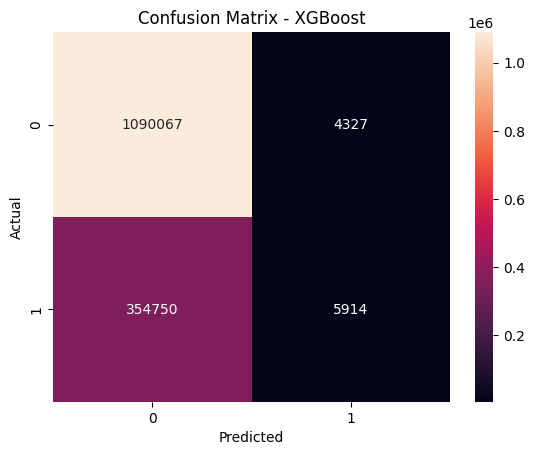

In [27]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure()
sns.heatmap(cm_xgb, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

    XGBoost Feature Importance Visualization

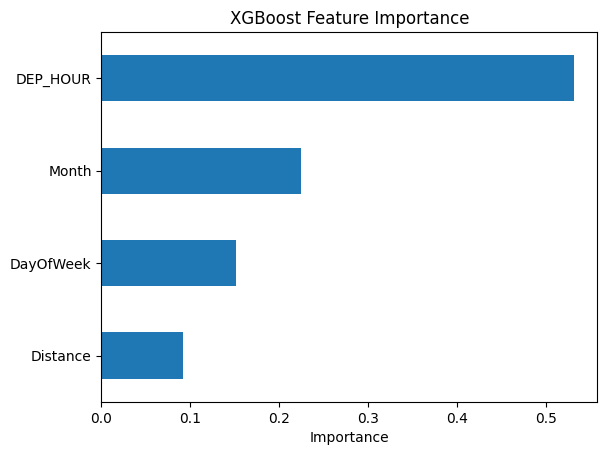

In [28]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=features
)

plt.figure()
xgb_importance.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.show()


# FINAL MODEL COMPARISON

Accuracy Comparison Table

In [29]:
accuracy_lr = accuracy_score(y_test, y_pred)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [accuracy_lr, accuracy_rf, accuracy_xgb]
})

print(comparison_df)


                 Model  Accuracy
0  Logistic Regression  0.752095
1        Random Forest  0.729522
2              XGBoost  0.753222


Model Accuracy Comparison Visualization

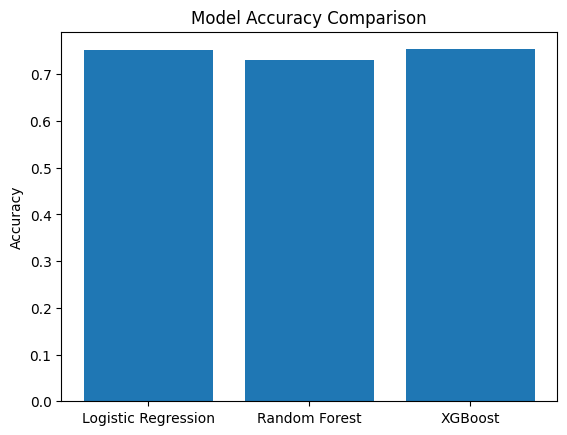

In [30]:
plt.figure()
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


Recall Comparison for Delayed Flights|

                 Model  Recall (Delayed Flights)
0  Logistic Regression                  0.000044
1        Random Forest                  0.232585
2              XGBoost                  0.016398


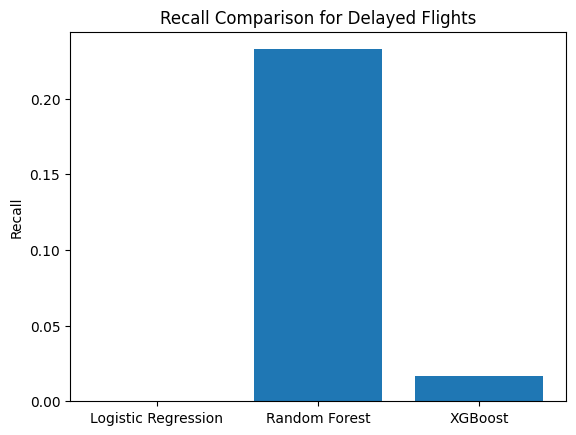

In [31]:
from sklearn.metrics import recall_score

recall_lr = recall_score(y_test, y_pred)
recall_rf = recall_score(y_test, y_pred_rf)
recall_xgb = recall_score(y_test, y_pred_xgb)

recall_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Recall (Delayed Flights)": [recall_lr, recall_rf, recall_xgb]
})

print(recall_df)

plt.figure()
plt.bar(recall_df["Model"], recall_df["Recall (Delayed Flights)"])
plt.ylabel("Recall")
plt.title("Recall Comparison for Delayed Flights")
plt.show()
